# Practical Session 4B: Waterfilling by Optimization and by Algorithm

This notebook covers the waterfilling tasks of the current script and compares the
direct convex optimization model with the classical closed-form algorithm.


In [1]:
# Import NumPy for vector operations.
import numpy as np
# Import pandas for comparison tables.
import pandas as pd
# Import cvxpy for the reference optimization solve.
import cvxpy as cp
# Import Matplotlib for the allocation visualization.
import matplotlib.pyplot as plt

# Format arrays in a compact way.
np.set_printoptions(precision=4, suppress=True)
# Choose an installed solver for the convex optimization model.
SOLVER = "CLARABEL" if "CLARABEL" in cp.installed_solvers() else "SCS"
# Fix the seed for the random channel tests.
rng = np.random.default_rng(321)

# Channel gains from the practical script.
g = np.array([0.8, 1.2, 0.5, 2.0, 1.5], dtype=float)
# Total power budget.
P = 10.0


## Task 4: Waterfilling by convex optimization

We solve the sum-rate maximization problem directly with `cvxpy` to obtain a numerical
reference solution.


In [2]:
# Create one nonnegative power variable per parallel channel.
# TODO: Create one nonnegative power variable per channel.
p = ...
# Maximize the sum of logarithmic channel rates.
# TODO: Formulate the convex waterfilling optimization problem.
waterfilling_problem = ...
waterfilling_problem.solve(solver=SOLVER)

# Extract the optimal power allocation and achieved sum rate.
p_cvx = p.value
sum_rate = np.sum(np.log(1 + g * p_cvx))

# Summarize the allocation channel by channel.
report = pd.DataFrame(
    {
        "gain": g,
        "power_cvxpy": p_cvx,
        "receives_zero_power": np.isclose(p_cvx, 0.0, atol=1e-6),
    },
    index=[f"channel_{i + 1}" for i in range(len(g))],
)
display(report)
print("Status:", waterfilling_problem.status)
print("Achieved sum rate:", sum_rate)


,gain,power_cvxpy,receives_zero_power
channel_1,0.8,1.800009,False
channel_2,1.2,2.216701,False
channel_3,0.5,1.049704,False
channel_4,2.0,2.550225,False
channel_5,1.5,2.383361,False


Status: optimal
Achieved sum rate: 5.9403510488232385


## Task 5: Classical waterfilling algorithm

The direct algorithm computes a common water level and then allocates
`p_i = max(mu - 1 / g_i, 0)` to each channel.


In [3]:
def waterfilling_algorithm(gains, total_power):
    # Inverse gains represent the base heights in the waterfilling picture.
    inverse_gains = 1.0 / gains
    # Sort the base heights so the active set can be identified sequentially.
    sorted_inverse = np.sort(inverse_gains)
    prefix_sum = 0.0
    water_level = None

    for k in range(1, len(gains) + 1):
        # Accumulate the k smallest base heights.
        prefix_sum += sorted_inverse[k - 1]
        # Compute the candidate water level for the first k active channels.
        # TODO: Compute the candidate water level for the first k channels.
        candidate_level = ...
        # Stop when the next base height would lie above the current water level.
        if k == len(gains) or candidate_level <= sorted_inverse[k]:
            water_level = candidate_level
            break

    # Convert the final water level into power allocations.
    # TODO: Convert the final water level into channel powers.
    allocation = ...
    return allocation, water_level


# Run the direct algorithm on the script instance.
p_algo, water_level = waterfilling_algorithm(g, P)
# Compare both methods entry by entry.
comparison_df = pd.DataFrame(
    {
        "power_cvxpy": p_cvx,
        "power_algorithm": p_algo,
        "absolute_deviation": np.abs(p_cvx - p_algo),
    }
)
display(comparison_df)
print("Water level:", water_level)
print("Maximum absolute deviation:", np.max(np.abs(p_cvx - p_algo)))


,power_cvxpy,power_algorithm,absolute_deviation
0,1.800009,1.800000,0.000009
1,2.216701,2.216667,0.000034
2,1.049704,1.050000,0.000296
3,2.550225,2.550000,0.000225
4,2.383361,2.383333,0.000028


Water level: 3.05
Maximum absolute deviation: 0.00029620948877084885


In [4]:
# Test the agreement of both methods on five additional random channel vectors.
random_test_rows = []
for test_id in range(1, 6):
    # Draw a positive gain vector for a new synthetic instance.
    gains = rng.uniform(0.3, 2.5, size=5)
    # Solve the instance with cvxpy as the numerical reference.
    p_var = cp.Variable(len(gains), nonneg=True)
    problem = cp.Problem(
        cp.Maximize(cp.sum(cp.log(1 + cp.multiply(gains, p_var)))),
        [cp.sum(p_var) <= P],
    )
    problem.solve(solver=SOLVER)
    p_reference = p_var.value
    # Solve the same instance with the direct waterfilling routine.
    p_direct, _ = waterfilling_algorithm(gains, P)
    random_test_rows.append(
        {
            "test_id": test_id,
            "max_abs_deviation": np.max(np.abs(p_reference - p_direct)),
            "allclose_at_1e-4": bool(np.allclose(p_reference, p_direct, atol=1e-4)),
            "allclose_at_1e-3": bool(np.allclose(p_reference, p_direct, atol=1e-3)),
        }
    )

# Display the agreement summary across all random tests.
random_test_df = pd.DataFrame(random_test_rows)
display(random_test_df)


,test_id,max_abs_deviation,allclose_at_1e-4,allclose_at_1e-3
0,1,0.000196,False,True
1,2,0.000119,False,True
2,3,0.000041,True,True
3,4,0.000381,False,True
4,5,0.000215,False,True


## Task 6: Visualization of the allocation structure

The final figure makes the waterfilling intuition visible: better channels have smaller
inverse-gain baselines and therefore receive more power.


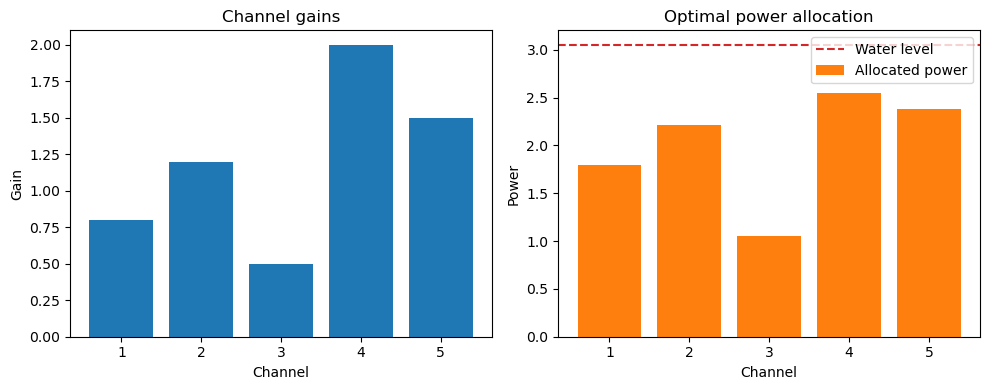

In [5]:
# Create one subplot for gains and one for the final power allocation.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot the raw channel gains.
axes[0].bar(np.arange(len(g)) + 1, g, color="tab:blue")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Gain")
axes[0].set_title("Channel gains")

# Plot the optimal powers and overlay the common water level.
axes[1].bar(np.arange(len(g)) + 1, p_algo, color="tab:orange", label="Allocated power")
axes[1].axhline(water_level, color="tab:red", linestyle="--", label="Water level")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Power")
axes[1].set_title("Optimal power allocation")
axes[1].legend()

plt.tight_layout()
plt.show()
